<a href="https://colab.research.google.com/github/OrastaRakhmatullayeva/ML-projects/blob/main/iris_random_forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Iris Classification — Random Forest Classifier

**Pipeline:**
Dataset → Split → Random Forest → Voting → Prediction → Evaluation


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## 2. Datasetni yuklash (Load Iris)

Iris dataseti 150 ta namunadan iborat, 4 ta feature va 3 ta klass

In [ ]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

pd.DataFrame(X, columns=feature_names).assign(target=y).head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 3. Train/Test split

Datasetni 80% train va 20% test qismlarga bo'lamiz. `stratify=y` har bir klass nisbati saqlanishini ta'minlaydi.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (120, 4)
Test shape: (30, 4)


## 4. Random Forest modelni o'qitish

- `n_estimators=100` — 100 ta daraxt
- `max_depth=None` — daraxtlar to'liq o'sishi mumkin
- `max_features="sqrt"` — har bir bo'linishda feature'larning kvadrat ildizi soni ko'rib chiqiladi
- `oob_score=True` — Out-of-Bag baholash yoqilgan

In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    max_features="sqrt",
    random_state=42,
    oob_score=True
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

## 5. Baholash: Accuracy va OOB score

In [ ]:
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
print(f"OOB score: {model.oob_score_:.4f}")

Accuracy: 0.9000
OOB score: 0.9417


## 6. Confusion Matrix

[[10  0  0]
 [ 0  9  1]
 [ 0  2  8]]


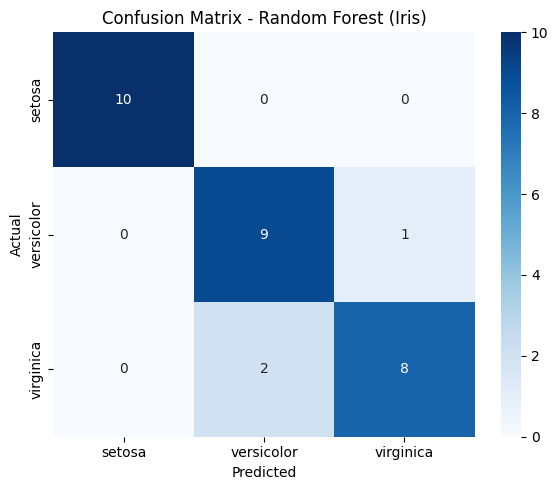

In [ ]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest (Iris)")
plt.tight_layout()
plt.show()

## 7. Classification Report

In [ ]:
print(classification_report(y_test, y_pred, target_names=target_names))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.82      0.90      0.86        10
   virginica       0.89      0.80      0.84        10

    accuracy                           0.90        30
   macro avg       0.90      0.90      0.90        30
weighted avg       0.90      0.90      0.90        30



## 8. Feature Importance

Random Forest har bir feature qarorlarga qay darajada ta'sir qilganini o'lchashga imkon beradi.

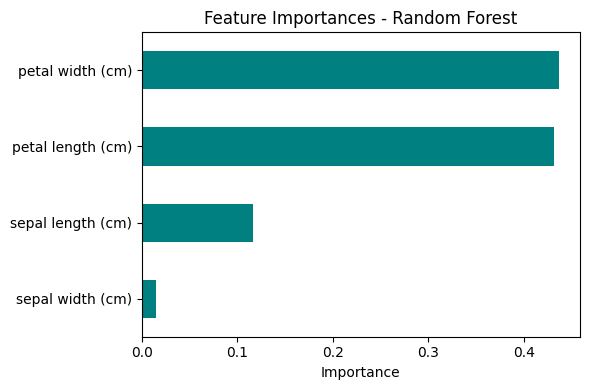

petal width (cm)     0.437185
petal length (cm)    0.431466
sepal length (cm)    0.116349
sepal width (cm)     0.015000
dtype: float64

In [ ]:
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(6, 4))
feat_imp.plot(kind="barh", color="teal")
plt.xlabel("Importance")
plt.title("Feature Importances - Random Forest")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

feat_imp

## 9. Mini-Experiment: n_estimators

`n_estimators` qiymatini 10 → 50 → 100 → 200 oralig'ida o'zgartirib, accuracy va OOB score'ni solishtiramiz.

In [ ]:
results = []
for n in [10, 50, 100, 200]:
    m = RandomForestClassifier(
        n_estimators=n,
        max_depth=None,
        max_features="sqrt",
        random_state=42,
        oob_score=True
    )
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    a = accuracy_score(y_test, pred)
    results.append({"n_estimators": n, "accuracy": a, "oob_score": m.oob_score_})

results_df = pd.DataFrame(results)
results_df

,n_estimators,accuracy,oob_score
0,10,0.966667,0.950000
1,50,0.900000,0.941667
2,100,0.900000,0.941667
3,200,0.900000,0.950000


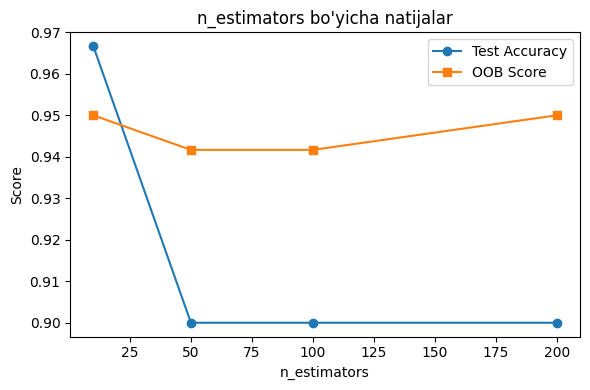

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(results_df["n_estimators"], results_df["accuracy"], marker="o", label="Test Accuracy")
plt.plot(results_df["n_estimators"], results_df["oob_score"], marker="s", label="OOB Score")
plt.xlabel("n_estimators")
plt.ylabel("Score")
plt.title("n_estimators bo'yicha natijalar")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Mini-Experiment: max_depth

`max_depth` qiymatini o'zgartirib, model chuqurligining natijaga ta'sirini ko'ramiz.

In [ ]:
depth_results = []
for d in [2, 3, 5, 10, None]:
    m = RandomForestClassifier(
        n_estimators=100,
        max_depth=d,
        max_features="sqrt",
        random_state=42,
        oob_score=True
    )
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    a = accuracy_score(y_test, pred)
    depth_results.append({"max_depth": d, "accuracy": a, "oob_score": m.oob_score_})

depth_df = pd.DataFrame(depth_results)
depth_df

,max_depth,accuracy,oob_score
0,2.0,0.900000,0.950000
1,3.0,0.966667,0.950000
2,5.0,0.933333,0.950000
3,10.0,0.900000,0.941667
4,NaN,0.900000,0.941667


## 11. Mini-Experiment: max_features

`max_features` parametrini ("sqrt", "log2", None) solishtiramiz.

In [ ]:
features_results = []
for f in ["sqrt", "log2", None]:
    m = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        max_features=f,
        random_state=42,
        oob_score=True
    )
    m.fit(X_train, y_train)
    pred = m.predict(X_test)
    a = accuracy_score(y_test, pred)
    features_results.append({"max_features": str(f), "accuracy": a, "oob_score": m.oob_score_})

features_df = pd.DataFrame(features_results)
features_df

,max_features,accuracy,oob_score
0,sqrt,0.900000,0.941667
1,log2,0.900000,0.941667
2,None,0.966667,0.950000


## Reflection

**1. Randomness qayerda?**
Ikki joyda: (1) *bootstrap sampling* — har bir daraxt uchun train datadan qaytarish bilan tasodifiy subsample olinadi; (2) *feature randomness* — `max_features="sqrt"` tufayli har bir tugunda bo'linish uchun barcha feature'lar emas, faqat tasodifiy tanlangan qismi ko'rib chiqiladi.

**2. Nega predictions birlashtiriladi?**
Bitta daraxt data'dagi shovqinga (noise) juda sezgir va oson overfit bo'ladi. Ko'plab mustaqil, bir-biriga o'xshamaydigan daraxtlarning ovozlarini birlashtirish (majority voting) xatolarni o'rtachalashtiradi — natijada variance kamayadi va model barqarorroq bo'ladi.

**3. n_estimators va max_depth nimani o'zgartiradi?**
- `n_estimators` — nechta daraxt qurilishini belgilaydi. Ko'proq daraxt odatda natijani barqarorlashtiradi (variance kamayadi), lekin hisoblash vaqti oshadi va ma'lum chegaradan keyin foyda kamayadi.
- `max_depth` — har bir daraxt qanchalik chuqur o'sishi mumkinligini cheklaydi. Juda chuqur → overfitting xavfi; juda sayoz → underfitting.

**4. Random Forest va bitta Tree o'rtasidagi asosiy farq nima?**
Bitta Decision Tree — deterministik, yuqori variance'ga ega, train data'ga juda moslashib ketadi (overfit). Random Forest esa ko'plab tasodifiylashtirilgan daraxtlarning ansamblidan iborat bo'lib, ularning natijalarini birlashtiradi — bu variance'ni kamaytiradi va generalization'ni yaxshilaydi, ammo interpretatsiya qilish qiyinroq ("black box"ga yaqinroq).